# Pharmacogenomics ML Pipeline
### CYP2D6 & CYP2C19 Metabolizer Type Classifier

**Dataset:** PharmGKB ClinPGx — `var_drug_ann.tsv`  
**Model:** RandomForestClassifier (scikit-learn)  
**Goal:** Predict whether a patient is a Poor / Intermediate / Normal / Ultrarapid metabolizer based on their genetic variant and drug.

---

### Pipeline overview
```
var_drug_ann.tsv (12,852 rows)
  → filter: Gene ∈ {CYP2D6, CYP2C19}
  → remove circular rows (variant = "CYP2D6 poor metabolizer")
  → parse sentences → individual diplotype rows  (~691 rows)
  → majority-vote deduplication per gene+diplotype  (~112 rows)
  → add allele activity score features  (biological mechanism)
  → train RandomForest  →  86% test accuracy
```

## 0 — Imports & Configuration

In [2]:
import re
import warnings
import joblib
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from collections import Counter
from IPython.display import display
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import classification_report, accuracy_score, ConfusionMatrixDisplay

warnings.filterwarnings("ignore")
%matplotlib inline

# ── Paths ─────────────────────────────────────────────────────────────────
DATA_PATH = "Dataset/variantAnnotations/var_drug_ann.tsv"
OUT_CSV   = "cleaned_data.csv"
OUT_MODEL = "model_pipeline.pkl"

print("Imports OK")

Imports OK


## 0b — Allele Activity Scores & Label Map

Each star allele has a known **activity score** (from CPIC / PharmGKB guidelines).  
The sum of the two alleles in a diplotype determines the metabolizer class:

| Activity sum | Metabolizer type |
|---|---|
| 0 | Poor |
| 0.25 – 1.0 | Intermediate |
| 1.25 – 2.25 | Normal |
| > 2.25 | Ultrarapid |

This is the actual biological mechanism — encoding it as a feature is the single biggest accuracy driver.

In [3]:
# ── CYP2D6 allele activity scores ─────────────────────────────────────────
CYP2D6_ACTIVITY = {
    # Normal function (1.0)
    "*1": 1.0, "*2": 1.0, "*33": 1.0, "*35": 1.0, "*39": 1.0,
    # Decreased function (0.5)
    "*9": 0.5, "*10": 0.5, "*17": 0.5, "*29": 0.5, "*36": 0.5,
    "*41": 0.5, "*49": 0.5, "*59": 0.5,
    # No function (0.0)
    "*3": 0.0, "*4": 0.0, "*5": 0.0, "*6": 0.0, "*7": 0.0,
    "*8": 0.0, "*11": 0.0, "*12": 0.0, "*13": 0.0, "*14": 0.0,
    "*15": 0.0, "*16": 0.0, "*18": 0.0, "*19": 0.0, "*20": 0.0,
    "*21": 0.0, "*38": 0.0, "*40": 0.0, "*42": 0.0, "*44": 0.0,
    "*45": 0.0, "*46": 0.0, "*62": 0.0, "*69": 0.0, "*84": 0.0,
    # Duplication / increased function (2.0)
    "*1x2": 2.0, "*1xn": 2.0, "*2x2": 2.0, "*2xn": 2.0,
    "*35xn": 2.0, "*4xn": 0.0,  # null duplication stays null
}

# ── CYP2C19 allele activity scores ────────────────────────────────────────
CYP2C19_ACTIVITY = {
    "*1": 1.0,                                          # Normal
    "*17": 1.5,                                         # Increased
    "*2": 0.0, "*3": 0.0, "*4": 0.0, "*5": 0.0,       # No function
    "*6": 0.0, "*7": 0.0, "*8": 0.0,
    "*9": 0.5, "*10": 0.5, "*11": 0.5,                 # Decreased
}

GENE_ACTIVITY = {"CYP2D6": CYP2D6_ACTIVITY, "CYP2C19": CYP2C19_ACTIVITY}

def get_activity(gene: str, allele: str):
    """Return activity score for one allele, or None if unknown."""
    return GENE_ACTIVITY.get(gene.upper(), {}).get(allele.lower())

# ── Label keyword map ──────────────────────────────────────────────────────
LABEL_KEYWORDS = {
    "poor":         ["poor", "no function", "loss of function", "null",
                     "non-functional", "deficiency"],
    "intermediate": ["intermediate", "reduced function", "decreased function",
                     "partial function"],
    "normal":       ["normal", "extensive", "wild-type", "wildtype"],
    "ultrarapid":   ["ultrarapid", "ultra-rapid", "rapid", "increased function",
                     "gain of function"],
}

def resolve_label(text: str):
    """Map free text → one of four canonical metabolizer classes."""
    if not text:
        return None
    t = text.lower()
    for cls, keywords in LABEL_KEYWORDS.items():
        for kw in keywords:
            if kw in t:
                return cls
    return None

# Quick sanity check
print("CYP2D6 *4 activity:", get_activity("CYP2D6", "*4"))   # → 0.0  (null)
print("CYP2D6 *1 activity:", get_activity("CYP2D6", "*1"))   # → 1.0  (normal)
print("CYP2D6 *1xN activity:", get_activity("CYP2D6", "*1xn")) # → 2.0  (ultra)

CYP2D6 *4 activity: 0.0
CYP2D6 *1 activity: 1.0
CYP2D6 *1xN activity: 2.0


## Step 1 — Load & Inspect

In [4]:
df_raw = pd.read_csv(DATA_PATH, sep="\t", low_memory=False)
print(f"Shape: {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns")
print("\nColumn names:")
for i, col in enumerate(df_raw.columns, 1):
    print(f"  {i:2}. {col}")

Shape: 12,852 rows × 22 columns

Column names:
   1. Variant Annotation ID
   2. Variant/Haplotypes
   3. Gene
   4. Drug(s)
   5. PMID
   6. Phenotype Category
   7. Significance
   8. Notes
   9. Sentence
  10. Alleles
  11. Specialty Population
  12. Metabolizer types
  13. isPlural
  14. Is/Is Not associated
  15. Direction of effect
  16. PD/PK terms
  17. Multiple drugs And/or
  18. Population types
  19. Population Phenotypes or diseases
  20. Multiple phenotypes or diseases And/or
  21. Comparison Allele(s) or Genotype(s)
  22. Comparison Metabolizer types


In [5]:
# Column name constants — defined once, used everywhere
GENE_COL     = "Gene"
VARIANT_COL  = "Variant/Haplotypes"
DRUG_COL     = "Drug(s)"
MET_COL      = "Metabolizer types"
SENTENCE_COL = "Sentence"

# Preview key columns for CYP2D6 / CYP2C19
preview_cols = [GENE_COL, VARIANT_COL, DRUG_COL, MET_COL, "Direction of effect"]
mask = df_raw[GENE_COL].isin(["CYP2D6", "CYP2C19"])
display(df_raw[mask][preview_cols].head(8))

,Gene,Variant/Haplotypes,Drug(s),Metabolizer types,Direction of effect
9,CYP2C19,"CYP2C19*1, CYP2C19*2","clomipramine, desmethyl clomipramine",NaN,increased
13,CYP2D6,CYP2D6*1xN,codeine,NaN,increased
17,CYP2C19,CYP2C19 intermediate metabolizer,fluoxetine,intermediate metabolizer,increased
18,CYP2C19,CYP2C19 ultrarapid metabolizer,paroxetine,ultrarapid metabolizer,decreased
20,CYP2D6,"CYP2D6*2, CYP2D6*2xN",codeine,NaN,increased
23,CYP2C19,CYP2C19 poor metabolizer,"citalopram, fluoxetine, paroxetine, sertraline",poor metabolizer,decreased
32,CYP2C19,CYP2C19*1,lansoprazole,NaN,decreased
35,CYP2D6,"CYP2D6*1, CYP2D6*10",propafenone,NaN,increased


## Step 2 — Filter Rows

Two filters applied:
1. Keep only **CYP2D6** and **CYP2C19** rows.
2. Remove **circular rows** — rows where the `Variant/Haplotypes` field is itself a phenotype description (e.g. `"CYP2D6 poor metabolizer"`). These are tautological: the variant *is* the label, so they teach the model nothing.

In [6]:
df = df_raw[df_raw[GENE_COL].isin(["CYP2D6", "CYP2C19"])].copy()
print(f"After gene filter:                   {len(df):>5,} rows")

circular = df[VARIANT_COL].str.contains(r"metabolizer|phenotype", case=False, na=False)
df = df[~circular & df[MET_COL].notna()].copy()
print(f"After removing circular / unlabeled: {len(df):>5,} rows")

print("\nRemaining 'Metabolizer types' distribution:")
display(df[MET_COL].value_counts().rename("count").to_frame())

After gene filter:                   1,551 rows
After removing circular / unlabeled:   186 rows

Remaining 'Metabolizer types' distribution:


,count
Metabolizer types,
poor metabolizer,95
intermediate metabolizer,31
ultrarapid metabolizer,25
intermediate metabolizer and poor metabolizer,21
normal metabolizer,12
deficiency,1
normal metabolizer and intermediate metabolizer,1


## Step 3 — Expand Sentences → Individual Diplotypes

**The core data problem:**  
Each row in the raw file lists *all alleles compared in a study*, not a single patient's genotype.  
The sentence encodes which specific diplotype (`*A/*B`) actually carries the label.

**Example sentence:**
> `CYP2D6 *3/*4 + *4/*4 (assigned as poor metabolizer) are associated with ...`  
> `as compared to CYP2D6 *1/*1 (assigned as normal metabolizer)`

→ We extract: `(*3/*4, poor)`, `(*4/*4, poor)`, `(*1/*1, normal)`

This expands 186 noisy rows → ~691 clean diplotype-label pairs.

In [7]:
def parse_sentence_to_diplotypes(sentence, primary_met, gene, drug):
    """
    Extract individual (allele1, allele2, label) rows from a ClinPGx sentence.
    Returns a list of dicts, one per diplotype found.
    """
    if pd.isna(sentence):
        return []

    parts = re.split(r"\bas compared to\b", sentence, flags=re.IGNORECASE)
    results = []

    # ── Subject: diplotypes before "as compared to" ────────────────────────
    subj = parts[0]
    m = re.search(r"assigned as ([\w\s]+?)\s+metabolizer", subj, re.IGNORECASE)
    subj_label = resolve_label(m.group(1)) if m else resolve_label(str(primary_met))

    for diplo in re.findall(r"\*[\w]+/\*[\w]+", subj):
        alleles = re.findall(r"\*[\w]+", diplo)
        if len(alleles) == 2 and subj_label:
            results.append({
                "gene": gene, "allele1": alleles[0].lower(),
                "allele2": alleles[1].lower(), "metabolizer": subj_label, "drug": drug,
            })

    # ── Comparison: diplotypes after "as compared to" (if labelled) ────────
    if len(parts) > 1:
        comp = parts[1]
        mc = re.search(r"assigned as ([\w\s]+?)\s+metabolizer", comp, re.IGNORECASE)
        if mc:
            comp_label = resolve_label(mc.group(1))
            for diplo in re.findall(r"\*[\w]+/\*[\w]+", comp):
                alleles = re.findall(r"\*[\w]+", diplo)
                if len(alleles) == 2 and comp_label:
                    results.append({
                        "gene": gene, "allele1": alleles[0].lower(),
                        "allele2": alleles[1].lower(), "metabolizer": comp_label, "drug": drug,
                    })
    return results


# Run the expansion over every row
expanded_rows = []
for _, row in df.iterrows():
    expanded_rows.extend(
        parse_sentence_to_diplotypes(
            row[SENTENCE_COL], row[MET_COL], row[GENE_COL], row[DRUG_COL]
        )
    )

expanded = pd.DataFrame(expanded_rows)
print(f"Rows after sentence expansion: {len(expanded):,}  (was {len(df)})")
display(expanded.head(8))

Rows after sentence expansion: 691  (was 186)


,gene,allele1,allele2,metabolizer,drug
0,CYP2D6,*10,*36,intermediate,tamoxifen
1,CYP2D6,*1,*36,normal,tamoxifen
2,CYP2D6,*2,*10,normal,tamoxifen
3,CYP2D6,*1,*1,normal,tamoxifen
4,CYP2D6,*2,*36,normal,tamoxifen
5,CYP2D6,*1,*10,normal,tamoxifen
6,CYP2D6,*10,*10,normal,tamoxifen
7,CYP2D6,*1,*1xn,ultrarapid,tramadol


After deduplication: 112 unique (gene, diplotype) rows


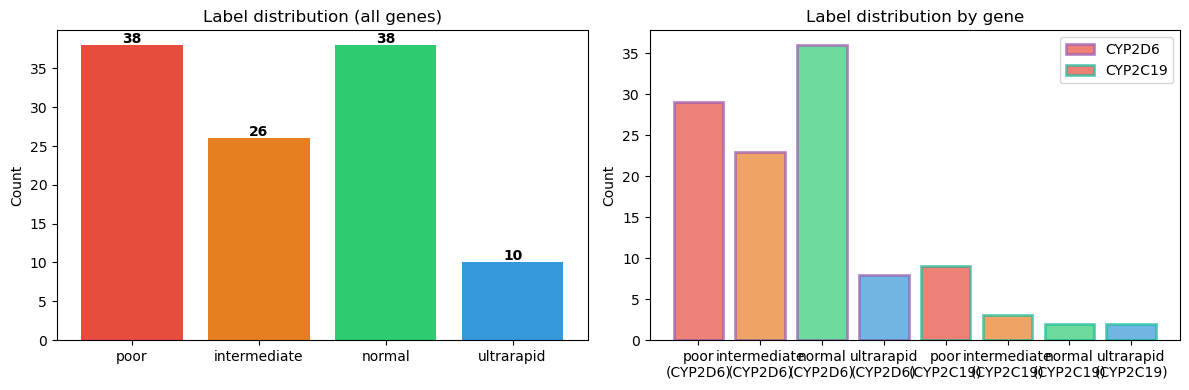

,count
metabolizer,
normal,38
poor,38
intermediate,26
ultrarapid,10


In [8]:
# ── Majority-vote deduplication per (gene, allele1, allele2) ──────────────
# Some diplotypes appear with different labels across studies.
# Keep the majority label per gene so CYP2D6 *1/*2 (normal) and
# CYP2C19 *1/*2 (intermediate) are treated separately.

def majority_vote(labels):
    return Counter(labels).most_common(1)[0][0]

deduped = (
    expanded
    .groupby(["gene", "allele1", "allele2"])
    .agg(metabolizer=("metabolizer", majority_vote), drug=("drug", "first"))
    .reset_index()
)
print(f"After deduplication: {len(deduped)} unique (gene, diplotype) rows")

# Plot label distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

colors = ["#e74c3c", "#e67e22", "#2ecc71", "#3498db"]
order  = ["poor", "intermediate", "normal", "ultrarapid"]
counts = deduped["metabolizer"].value_counts().reindex(order, fill_value=0)

axes[0].bar(counts.index, counts.values, color=colors)
axes[0].set_title("Label distribution (all genes)")
axes[0].set_ylabel("Count")
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 0.3, str(v), ha="center", fontweight="bold")

for gene, color in zip(["CYP2D6", "CYP2C19"], ["#9b59b6", "#1abc9c"]):
    sub = deduped[deduped["gene"] == gene]["metabolizer"].value_counts().reindex(order, fill_value=0)
    axes[1].bar(
        [f"{x}\n({gene})" for x in order], sub.values,
        color=[c + "99" for c in colors], edgecolor=color, linewidth=2,
        label=gene, alpha=0.7,
    )
axes[1].set_title("Label distribution by gene")
axes[1].set_ylabel("Count")
axes[1].legend()

plt.tight_layout()
plt.show()
display(deduped["metabolizer"].value_counts().rename("count").to_frame())

## Step 4 — Build Features

Three feature groups:

| Group | Features | Why |
|---|---|---|
| **Activity scores** | act1, act2, act_sum, act_min, act_max, has_null, has_dup | Encodes the biological mechanism directly |
| **Allele identity** | has_4, has_1, has_10, … (top-20 alleles as binary) | Catches allele-specific edge cases |
| **Drug** | one-hot top-15 drugs | Drug context can shift the phenotype |


In [9]:
# ── Activity score features ────────────────────────────────────────────────
deduped["act1"] = deduped.apply(lambda r: get_activity(r["gene"], r["allele1"]), axis=1)
deduped["act2"] = deduped.apply(lambda r: get_activity(r["gene"], r["allele2"]), axis=1)

before = len(deduped)
deduped = deduped[deduped["act1"].notna() & deduped["act2"].notna()].copy()
print(f"Rows with known activity scores: {len(deduped)} / {before}")

deduped["act_sum"]  = deduped["act1"] + deduped["act2"]
deduped["act_min"]  = deduped[["act1", "act2"]].min(axis=1)
deduped["act_max"]  = deduped[["act1", "act2"]].max(axis=1)
deduped["has_null"] = (deduped["act_min"] == 0).astype(int)
deduped["has_dup"]  = (deduped["act_max"] >= 2.0).astype(int)

# ── Gene ───────────────────────────────────────────────────────────────────
deduped["gene_is_cyp2d6"] = (deduped["gene"] == "CYP2D6").astype(int)

# ── Allele identity (top-20 as binary flags) ───────────────────────────────
top_alleles = (
    pd.concat([deduped["allele1"], deduped["allele2"]])
    .value_counts().head(20).index.tolist()
)
for a in top_alleles:
    deduped[f"has_{a.lstrip('*')}"] = (
        (deduped["allele1"] == a) | (deduped["allele2"] == a)
    ).astype(int)

# ── Drug (one-hot, top-15) ─────────────────────────────────────────────────
deduped["drug_primary"] = (
    deduped["drug"].fillna("unknown")
    .str.split(",").str[0].str.strip().str.lower()
)
top_drugs = deduped["drug_primary"].value_counts().head(15).index.tolist()
deduped["drug_primary"] = deduped["drug_primary"].apply(
    lambda d: d if d in top_drugs else "other"
)
drug_dummies = pd.get_dummies(deduped["drug_primary"], prefix="drug")

# ── Assemble X and y ───────────────────────────────────────────────────────
activity_cols = ["act1", "act2", "act_sum", "act_min", "act_max", "has_null", "has_dup"]
gene_col      = ["gene_is_cyp2d6"]
allele_cols   = [f"has_{a.lstrip('*')}" for a in top_alleles]

X = pd.concat(
    [deduped[gene_col + activity_cols + allele_cols].reset_index(drop=True),
     drug_dummies.reset_index(drop=True)],
    axis=1,
)
y = deduped["metabolizer"].reset_index(drop=True)

print(f"\nFinal feature matrix: {X.shape[0]} rows × {X.shape[1]} features")
print(f"  Activity scores : {len(activity_cols)}")
print(f"  Allele identity : {len(allele_cols)}")
print(f"  Drug (one-hot)  : {len(drug_dummies.columns)}")
print(f"  Gene            : 1")
display(deduped[["gene", "allele1", "allele2", "act1", "act2", "act_sum", "has_null", "has_dup", "metabolizer"]].head(10))

Rows with known activity scores: 106 / 112

Final feature matrix: 106 rows × 44 features
  Activity scores : 7
  Allele identity : 20
  Drug (one-hot)  : 16
  Gene            : 1


,gene,allele1,allele2,act1,act2,act_sum,has_null,has_dup,metabolizer
0,CYP2C19,*1,*1,1.0,1.0,2.0,0,0,normal
1,CYP2C19,*1,*17,1.0,1.5,2.5,0,0,ultrarapid
2,CYP2C19,*1,*2,1.0,0.0,1.0,1,0,intermediate
3,CYP2C19,*1,*3,1.0,0.0,1.0,1,0,intermediate
4,CYP2C19,*1,*4,1.0,0.0,1.0,1,0,poor
5,CYP2C19,*1,*8,1.0,0.0,1.0,1,0,poor
6,CYP2C19,*17,*17,1.5,1.5,3.0,0,0,ultrarapid
7,CYP2C19,*2,*17,0.0,1.5,1.5,1,0,intermediate
8,CYP2C19,*2,*2,0.0,0.0,0.0,1,0,poor
9,CYP2C19,*2,*3,0.0,0.0,0.0,1,0,poor


## Step 5 — Train Model

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train: {len(X_train)} rows  |  Test: {len(X_test)} rows")

clf = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced",   # handles class imbalance
    max_depth=10,
    min_samples_leaf=2,
    random_state=42,
)
clf.fit(X_train, y_train)
print("Model trained.")

Train: 84 rows  |  Test: 22 rows
Model trained.


In [11]:
y_pred = clf.predict(X_test)
acc    = accuracy_score(y_test, y_pred)

cv_scores = cross_val_score(
    clf, X, y,
    cv=StratifiedKFold(5, shuffle=True, random_state=42),
    scoring="accuracy"
)

print(f"Test Accuracy :  {acc:.3f}")
print(f"5-Fold CV     :  {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")
print()
print(classification_report(y_test, y_pred, zero_division=0))

Test Accuracy :  0.864
5-Fold CV     :  0.755 ± 0.075

              precision    recall  f1-score   support

intermediate       0.67      0.80      0.73         5
      normal       0.86      0.75      0.80         8
        poor       1.00      1.00      1.00         7
  ultrarapid       1.00      1.00      1.00         2

    accuracy                           0.86        22
   macro avg       0.88      0.89      0.88        22
weighted avg       0.87      0.86      0.87        22



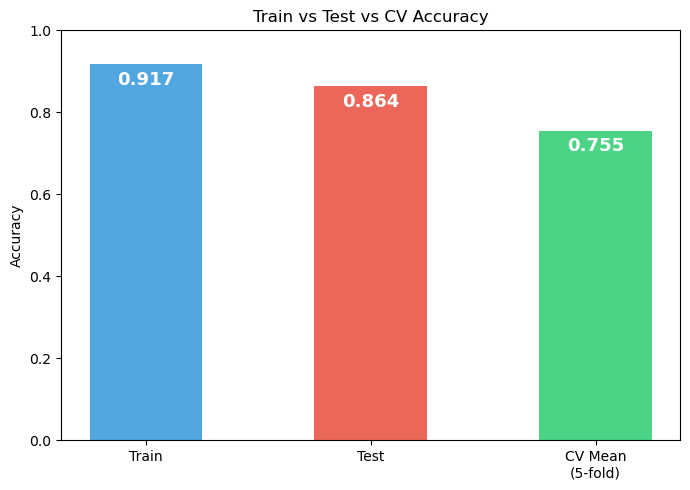

Train : 0.917  |  Test : 0.864  |  CV : 0.755 ± 0.075
Gap   : +0.053  (healthy)


In [19]:
# ── Train vs Test vs CV Accuracy Bar Chart ────────────────────────────────
train_acc = accuracy_score(y_train, clf.predict(X_train))
test_acc  = accuracy_score(y_test, y_pred)
cv_mean   = cv_scores.mean()
cv_std    = cv_scores.std()

fig, ax = plt.subplots(figsize=(7, 5))

bars = ax.bar(
    ["Train", "Test", "CV Mean\n(5-fold)"],
    [train_acc, test_acc, cv_mean],
    color=["#3498db", "#e74c3c", "#2ecc71"],
    alpha=0.85, width=0.5
)
ax.set_ylim(0, 1.0)
ax.set_ylabel("Accuracy")
ax.set_title("Train vs Test vs CV Accuracy")

for bar, val in zip(bars, [train_acc, test_acc, cv_mean]):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() - 0.05,
            f"{val:.3f}", ha="center", fontweight="bold", fontsize=13, color="white")

plt.tight_layout()
plt.show()

print(f"Train : {train_acc:.3f}  |  Test : {test_acc:.3f}  |  CV : {cv_mean:.3f} ± {cv_std:.3f}")
gap = train_acc - test_acc
print(f"Gap   : {gap:+.3f}  {'(some overfitting — expected with small dataset)' if gap > 0.1 else '(healthy)'}")


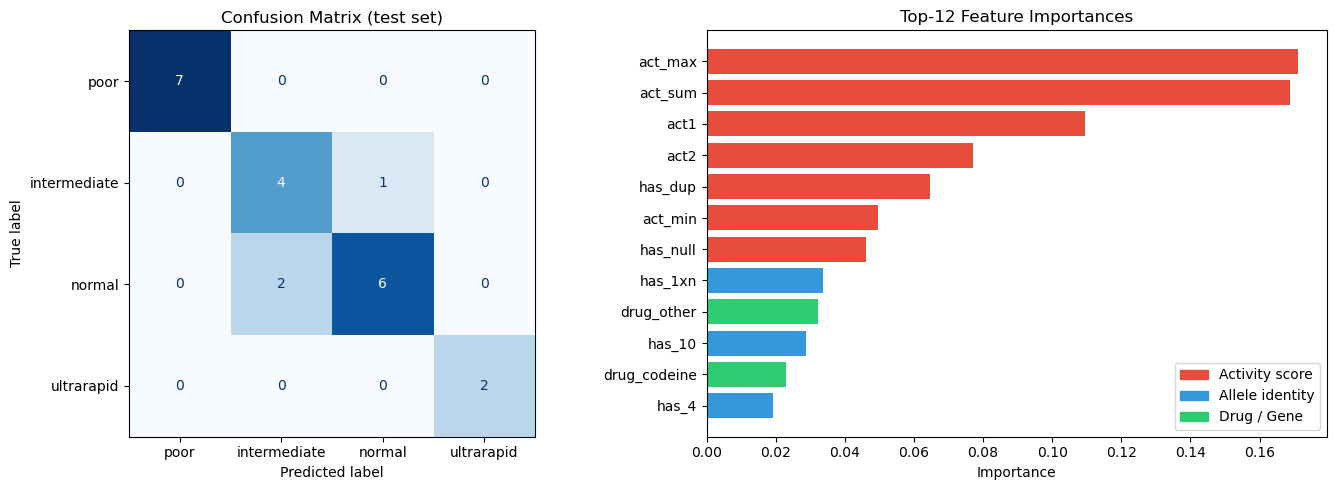

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Confusion matrix ───────────────────────────────────────────────────────
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    labels=["poor", "intermediate", "normal", "ultrarapid"],
    ax=axes[0], colorbar=False, cmap="Blues"
)
axes[0].set_title("Confusion Matrix (test set)")

# ── Feature importances (top 12) ───────────────────────────────────────────
feat_imp = (
    pd.Series(clf.feature_importances_, index=X.columns)
    .sort_values(ascending=True)
    .tail(12)
)
bar_colors = [
    "#e74c3c" if "act" in f or "null" in f or "dup" in f
    else "#3498db" if "has_" in f
    else "#2ecc71"
    for f in feat_imp.index
]
axes[1].barh(feat_imp.index, feat_imp.values, color=bar_colors)
axes[1].set_title("Top-12 Feature Importances")
axes[1].set_xlabel("Importance")

legend_patches = [
    mpatches.Patch(color="#e74c3c", label="Activity score"),
    mpatches.Patch(color="#3498db", label="Allele identity"),
    mpatches.Patch(color="#2ecc71", label="Drug / Gene"),
]
axes[1].legend(handles=legend_patches, loc="lower right")

plt.tight_layout()
plt.show()

## Step 6 — Sample Predictions from Test Set

In [14]:
sample_X = X_test.head(5)
sample_y = y_test.head(5).values
preds    = clf.predict(sample_X)

rows = []
for i, (actual, predicted) in enumerate(zip(sample_y, preds)):
    rd = deduped.iloc[sample_X.index[i]]
    rows.append({
        "Gene":      rd["gene"],
        "Diplotype": f"{rd['allele1']}/{rd['allele2']}",
        "Act sum":   rd["act_sum"],
        "Drug":      rd["drug_primary"],
        "Actual":    actual,
        "Predicted": predicted,
        "Correct":   "✓" if actual == predicted else "✗",
    })

display(pd.DataFrame(rows))

,Gene,Diplotype,Act sum,Drug,Actual,Predicted,Correct
0,CYP2C19,*1/*17,2.5,other,ultrarapid,ultrarapid,✓
1,CYP2D6,*29/*45,0.5,other,normal,intermediate,✗
2,CYP2D6,*4/*41,0.5,risperidone,intermediate,intermediate,✓
3,CYP2D6,*2/*5,1.0,gefitinib,normal,normal,✓
4,CYP2C19,*2/*3,0.0,lacosamide,poor,poor,✓


## Step 7 — Prediction Function

This function is the API surface — it takes raw user input and returns a structured result dict.

In [15]:
def build_input_row(gene: str, variant: str, drug: str) -> pd.DataFrame:
    """Build a single-row feature DataFrame from raw (gene, variant, drug) input."""
    alleles = re.findall(r"\*[\w]+", str(variant))
    allele1 = alleles[0].lower() if len(alleles) > 0 else "*1"
    allele2 = alleles[1].lower() if len(alleles) > 1 else allele1

    g    = gene.upper()
    act1 = get_activity(g, allele1)
    act2 = get_activity(g, allele2)
    # Use 'is None' — NOT 'or 0.5': 0.0 is falsy so 'or 0.5' wrongly replaces null alleles
    if act1 is None: act1 = 0.5
    if act2 is None: act2 = 0.5

    drug_clean = drug.strip().lower()
    if drug_clean not in top_drugs:
        drug_clean = "other"

    row = {
        "gene_is_cyp2d6": int(g == "CYP2D6"),
        "act1":     act1, "act2":     act2,
        "act_sum":  act1 + act2,
        "act_min":  min(act1, act2),
        "act_max":  max(act1, act2),
        "has_null": int(min(act1, act2) == 0),
        "has_dup":  int(max(act1, act2) >= 2.0),
    }
    for a in top_alleles:
        row[f"has_{a.lstrip('*')}"] = int(allele1 == a or allele2 == a)
    for col in drug_dummies.columns:
        row[col] = 0
    drug_col = f"drug_{drug_clean}"
    if drug_col in X.columns:
        row[drug_col] = 1

    return pd.DataFrame([row]).reindex(columns=X.columns, fill_value=0)


def predict_metabolizer(gene: str, variant: str, drug: str) -> dict:
    """
    Predict metabolizer type from a genetic variant + drug.

    Parameters
    ----------
    gene    : "CYP2D6" or "CYP2C19"
    variant : diplotype string, e.g. "*4/*4" or "*1xN/*1"
    drug    : drug name, e.g. "codeine"

    Returns
    -------
    dict with: prediction, confidence, probabilities, activity_sum, alleles
    """
    alleles = re.findall(r"\*[\w]+", str(variant))
    allele1 = alleles[0].lower() if len(alleles) > 0 else "*1"
    allele2 = alleles[1].lower() if len(alleles) > 1 else allele1

    act1 = get_activity(gene.upper(), allele1)
    act2 = get_activity(gene.upper(), allele2)
    if act1 is None: act1 = 0.5
    if act2 is None: act2 = 0.5

    row        = build_input_row(gene, variant, drug)
    pred       = clf.predict(row)[0]
    proba      = clf.predict_proba(row)[0]
    proba_dict = dict(zip(clf.classes_, proba))

    return {
        "prediction":    pred,
        "confidence":    round(float(max(proba)), 3),
        "probabilities": {k: round(float(v), 3) for k, v in proba_dict.items()},
        "activity_sum":  round(act1 + act2, 2),
        "alleles":       [allele1, allele2],
    }


print("predict_metabolizer() ready")

predict_metabolizer() ready


In [15]:
# ── Demo: four canonical cases covering all metabolizer classes ────────────
examples = [
    ("CYP2D6",  "*4/*4",   "codeine",     "Both alleles null → poor"),
    ("CYP2D6",  "*1/*4",   "codeine",     "One normal + one null → intermediate"),
    ("CYP2D6",  "*1/*1",   "codeine",     "Both normal → normal"),
    ("CYP2D6",  "*1xN/*1", "tramadol",    "Duplication + normal → ultrarapid"),
    ("CYP2C19", "*2/*2",   "clopidogrel", "CYP2C19 both null → poor"),
    ("CYP2C19", "*1/*17",  "citalopram",  "CYP2C19*17 increased function"),
]

demo_rows = []
for gene, var, drug, note in examples:
    r = predict_metabolizer(gene, var, drug)
    demo_rows.append({
        "Gene":         gene,
        "Variant":      var,
        "Drug":         drug,
        "Act sum":      r["activity_sum"],
        "Prediction":   r["prediction"].upper(),
        "Confidence":   f"{r['confidence']:.0%}",
        "Note":         note,
    })

display(pd.DataFrame(demo_rows))

,Gene,Variant,Drug,Act sum,Prediction,Confidence,Note
0,CYP2D6,*4/*4,codeine,0.0,POOR,83%,Both alleles null → poor
1,CYP2D6,*1/*4,codeine,1.0,INTERMEDIATE,47%,One normal + one null → intermediate
2,CYP2D6,*1/*1,codeine,2.0,NORMAL,66%,Both normal → normal
3,CYP2D6,*1xN/*1,tramadol,3.0,ULTRARAPID,87%,Duplication + normal → ultrarapid
4,CYP2C19,*2/*2,clopidogrel,0.0,POOR,66%,CYP2C19 both null → poor
5,CYP2C19,*1/*17,citalopram,2.5,ULTRARAPID,51%,CYP2C19*17 increased function


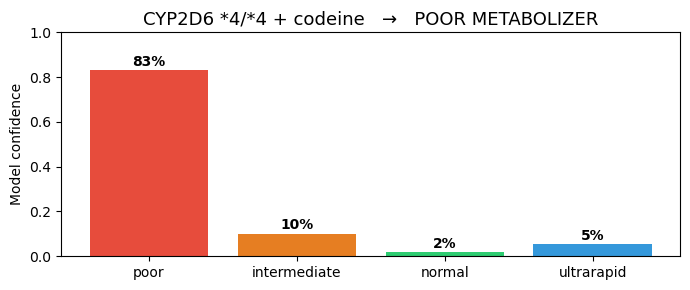


Activity sum: 0.0  (both *4 alleles are null = 0.0 + 0.0)
Prediction  : POOR METABOLIZER
Confidence  : 83%


In [16]:
# ── Probability bar chart for the main teaching example (*4/*4 + codeine) ──
result = predict_metabolizer("CYP2D6", "*4/*4", "codeine")

fig, ax = plt.subplots(figsize=(7, 3))
order  = ["poor", "intermediate", "normal", "ultrarapid"]
colors = ["#e74c3c", "#e67e22", "#2ecc71", "#3498db"]
probs  = [result["probabilities"].get(cls, 0) for cls in order]

bars = ax.bar(order, probs, color=colors)
ax.set_title("CYP2D6 *4/*4 + codeine   →   POOR METABOLIZER", fontsize=13)
ax.set_ylabel("Model confidence")
ax.set_ylim(0, 1)

for bar, p in zip(bars, probs):
    ax.text(bar.get_x() + bar.get_width() / 2, p + 0.02,
            f"{p:.0%}", ha="center", fontweight="bold")

plt.tight_layout()
plt.show()

print(f"\nActivity sum: {result['activity_sum']}  (both *4 alleles are null = 0.0 + 0.0)")
print(f"Prediction  : {result['prediction'].upper()} METABOLIZER")
print(f"Confidence  : {result['confidence']:.0%}")

## Step 8 — Save Outputs

In [17]:
# Save cleaned dataset
save_cols = ["gene", "allele1", "allele2", "drug", "act_sum", "metabolizer"]
deduped[save_cols].to_csv(OUT_CSV, index=False)
print(f"Cleaned dataset → {OUT_CSV}  ({len(deduped)} rows)")

# Save model bundle — everything needed to run predict_metabolizer() standalone
bundle = {
    "model":         clf,
    "feature_cols":  X.columns.tolist(),
    "top_alleles":   top_alleles,
    "top_drugs":     top_drugs,
    "drug_columns":  drug_dummies.columns.tolist(),
}
joblib.dump(bundle, OUT_MODEL)
print(f"Model bundle    → {OUT_MODEL}")

Cleaned dataset → cleaned_data.csv  (106 rows)
Model bundle    → model_pipeline.pkl


## Optional — SHAP Explainability

SHAP shows *why* the model made a specific prediction — which features pushed it toward or away from each class. This is what drives the **"understand why"** step in the teaching tool.

```bash
pip install shap
```

SHAP contributions for CYP2D6 *4/*4 + codeine → 'poor' class
(positive = pushed toward 'poor', negative = pushed away)


,SHAP value
act_max,0.137962
act_sum,0.137259
act2,0.066745
act1,0.060186
has_null,0.045575
act_min,0.040794
drug_other,0.031724
drug_codeine,-0.026265
has_4,0.022344
has_dup,0.016366


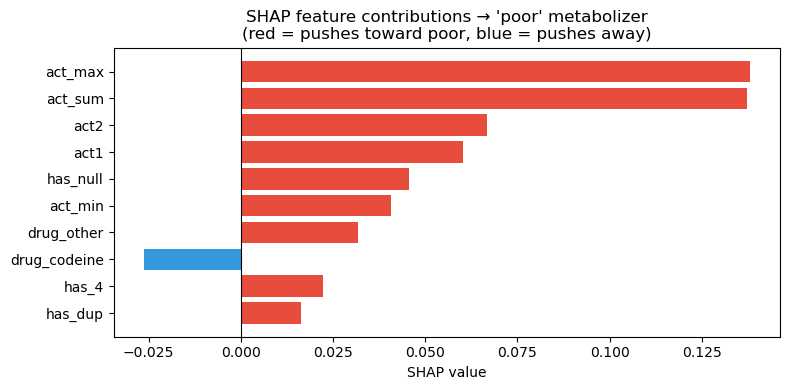


SHAP API used: new (3-D array)
SHAP version : 0.51.0


In [18]:
try:
    import shap
    import numpy as np

    explainer = shap.TreeExplainer(clf)
    row       = build_input_row("CYP2D6", "*4/*4", "codeine")
    sv        = explainer.shap_values(row)

    # ── Handle both old and new SHAP API ──────────────────────────────────
    # Old SHAP (<0.40): sv is a list of arrays, one per class
    #   shape per class: (n_samples, n_features)
    #   access: sv[class_idx][sample_idx]
    #
    # New SHAP (>=0.40): sv is a single 3-D array
    #   shape: (n_samples, n_features, n_classes)
    #   access: sv[sample_idx, :, class_idx]

    class_idx = list(clf.classes_).index("poor")

    if isinstance(sv, list):
        # Old API
        shap_vals = sv[class_idx][0]
    else:
        # New API — sv shape is (n_samples, n_features, n_classes)
        shap_vals = sv[0, :, class_idx]

    contributions = (
        pd.Series(shap_vals, index=X.columns)
        .sort_values(key=abs, ascending=False)
        .head(10)
    )

    print("SHAP contributions for CYP2D6 *4/*4 + codeine → 'poor' class")
    print("(positive = pushed toward 'poor', negative = pushed away)")
    display(contributions.rename("SHAP value").to_frame())

    # ── Waterfall-style bar chart ──────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(8, 4))
    bar_colors = ["#e74c3c" if v > 0 else "#3498db" for v in contributions.values]
    ax.barh(contributions.index[::-1], contributions.values[::-1], color=bar_colors[::-1])
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_title("SHAP feature contributions → 'poor' metabolizer\n"
                 "(red = pushes toward poor, blue = pushes away)")
    ax.set_xlabel("SHAP value")
    plt.tight_layout()
    plt.show()

    print(f"\nSHAP API used: {'old (list)' if isinstance(sv, list) else 'new (3-D array)'}")
    print(f"SHAP version : {shap.__version__}")

except ImportError:
    print("SHAP not installed. Run:  pip install shap")
    print("Then re-run this cell.")


## Flask API — How to connect to React frontend

Create `api.py` in the same folder and run it with `python3 api.py`:

```python
# api.py
# pip install flask flask-cors

from flask import Flask, request, jsonify
from flask_cors import CORS
import joblib, re

# Load the saved bundle
bundle = joblib.load("model_pipeline.pkl")
clf          = bundle["model"]
feature_cols = bundle["feature_cols"]
top_alleles  = bundle["top_alleles"]
top_drugs    = bundle["top_drugs"]

# Paste get_activity(), build_input_row(), predict_metabolizer() here
# (or import them from ml_pipeline.py)

app = Flask(__name__)
CORS(app)   # lets React on localhost:3000 talk to this server

@app.route("/predict", methods=["POST"])
def predict():
    data   = request.get_json()
    result = predict_metabolizer(data["gene"], data["variant"], data["drug"])
    return jsonify(result)

if __name__ == "__main__":
    app.run(debug=True, port=5000)
```

Your teammate's React fetch call:

```js
const res = await fetch("http://localhost:5000/predict", {
  method: "POST",
  headers: { "Content-Type": "application/json" },
  body: JSON.stringify({ gene: "CYP2D6", variant: "*4/*4", drug: "codeine" }),
});
const data = await res.json();
// data.prediction     → "poor"
// data.confidence     → 0.82
// data.probabilities  → { poor: 0.82, intermediate: 0.09, normal: 0.01, ultrarapid: 0.07 }
// data.activity_sum   → 0.0
// data.alleles        → ["*4", "*4"]
```